<a href="https://colab.research.google.com/github/UmymaM/DeepFake-Detection/blob/main/src/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

In [2]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile as zf
import os
import cv2

In [5]:
with zf.ZipFile("/content/drive/MyDrive/archive (1).zip","r") as zip_ref:
  zip_ref.extractall("/content")

In [6]:
df=pd.read_csv("/content/my_real_vs_ai_dataset/my_real_vs_ai_dataset/augmentation_log.csv")

In [7]:
df.head()

,Original_Image,Augmented_Image,Augmentation_Type
0,Q3S6DA4SUP.jpg,aug_ai_00001.jpg,horizontal_flip
1,1024_woman_SD_0568.jpg,aug_ai_00002.jpg,masking
2,6AF61RJWBX.jpg,aug_ai_00003.jpg,masking
3,KMDYF02IK2.jpg,aug_ai_00004.jpg,rotation
4,5ABZN4ISJF.jpg,aug_ai_00005.jpg,color_jitter


In [8]:
df.describe()

,Original_Image,Augmented_Image,Augmentation_Type
count,4895,4895,4895
unique,4792,4895,7
top,dfdc_train_fake_bahdpoesir_130_0.jpg,aug_ai_04895.jpg,masking
freq,3,1,719


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4895 entries, 0 to 4894
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Original_Image     4895 non-null   object
 1   Augmented_Image    4895 non-null   object
 2   Augmentation_Type  4895 non-null   object
dtypes: object(3)
memory usage: 114.9+ KB


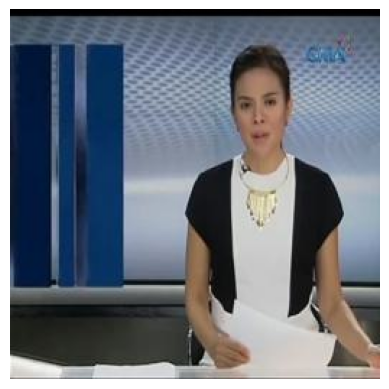

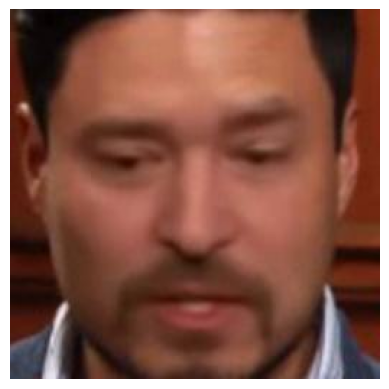

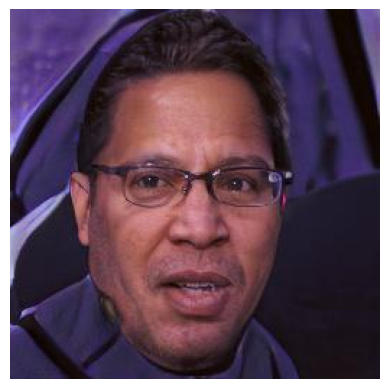

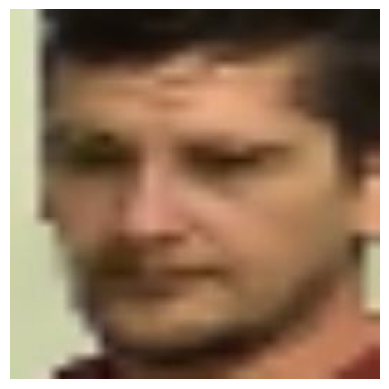

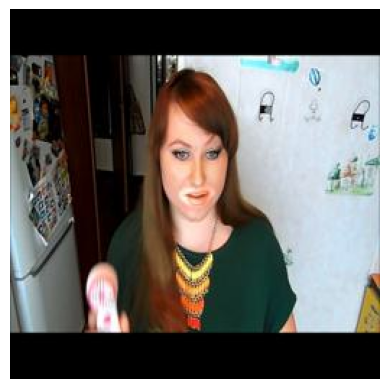

In [10]:
ai_images_path="/content/my_real_vs_ai_dataset/my_real_vs_ai_dataset/ai_images"
for idx,file in enumerate(os.listdir(ai_images_path)):
  img_path=os.path.join(ai_images_path,file)
  image=(cv2.imread(img_path))
  image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  plt.imshow(image_rgb)
  plt.axis("off")
  plt.show()
  if idx==4: break


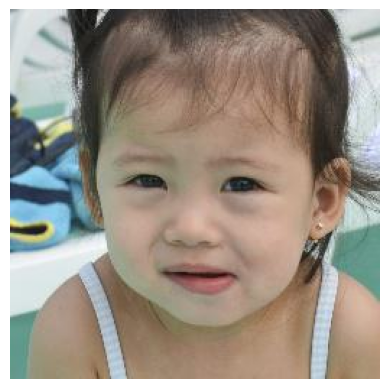

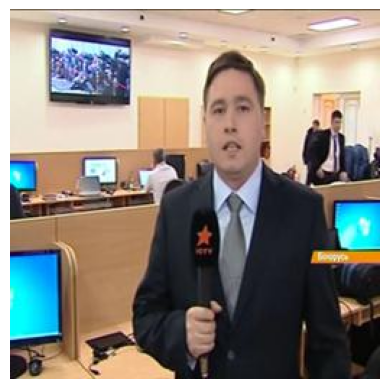

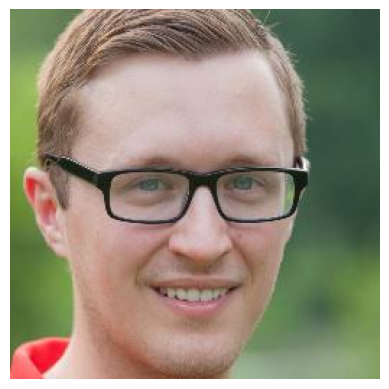

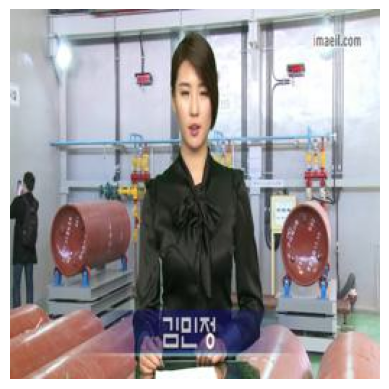

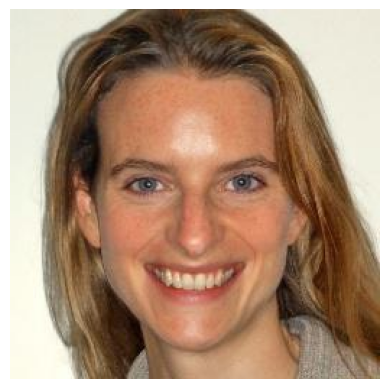

In [11]:
real_images_path="/content/my_real_vs_ai_dataset/my_real_vs_ai_dataset/real"
for idx,file in enumerate(os.listdir(real_images_path)):
  img_path=os.path.join(real_images_path,file)
  image=(cv2.imread(img_path))
  image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  plt.imshow(image_rgb)
  plt.axis("off")
  plt.show()
  if idx==4: break


In [12]:
print(f"AI Images: {len(os.listdir(ai_images_path))}")
print(f"Real Images: {len(os.listdir(real_images_path))}")

AI Images: 100000
Real Images: 100000


## Building Datset

In [13]:
real_images=[]
ai_images=[]
for file in os.listdir(real_images_path):
  image_data=[]
  img_path=os.path.join(real_images_path,file)
  image_data.append(img_path)
  image_data.append(0) #0->real
  real_images.append(image_data)
for file in os.listdir(ai_images_path):
  image_data=[]
  img_path=os.path.join(ai_images_path,file)
  image_data.append(img_path)
  image_data.append(1) #1->real
  ai_images.append(image_data)
print(f"Real Images: {len(real_images)}")
print(f"AI Images: {len(ai_images)}")

Real Images: 100000
AI Images: 100000


In [14]:
ds=real_images+ai_images
df=pd.DataFrame(ds,columns=["image_path","label"])
df.head()

,image_path,label
0,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
1,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
2,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
3,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
4,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0


In [15]:
shuffled_df=df.sample(frac=1).reset_index(drop=True)
shuffled_df.head()

,image_path,label
0,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,1
1,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
2,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,1
3,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,1
4,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,1


In [16]:
shuffled_df.label.unique()

array([1, 0])

In [17]:
shuffled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   image_path  200000 non-null  object
 1   label       200000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [18]:
shuffled_df.duplicated().sum()

np.int64(0)

In [19]:
shuffled_df.isnull().sum()

,0
image_path,0
label,0


In [21]:
shuffled_df.to_csv("/content/drive/MyDrive/metadata.csv", index=False)

## Splitting Data

In [25]:
shuffled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   image_path  200000 non-null  object
 1   label       200000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [26]:
shuffled_df.tail()

,image_path,label
199995,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,1
199996,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
199997,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0
199998,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,1
199999,/content/my_real_vs_ai_dataset/my_real_vs_ai_d...,0


In [30]:
total=len(shuffled_df)
train_df=shuffled_df.iloc[:int(0.7*total)]
test_df=shuffled_df[int(0.7*total):int(0.85*total)]
val_df=shuffled_df[int(0.85*total):]

In [32]:
train_df.to_csv("/content/drive/MyDrive/train_metadata.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/test_metadata.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/val_metadata.csv", index=False)